# 🧮 Task 4 — Portfolio Optimization & Efficient Frontier

**Objective:**  
Use Task 3 ARIMA forecasts to compute expected returns, portfolio risk, and optimize asset allocation.

**Outputs:**  
- Efficient frontier plot  
- Max Sharpe and Min Volatility portfolios  
- Risk-return tables for presentation  


In [3]:
# %% [code]
import sys
import os

# Add repo root to Python path
repo_root = os.path.abspath("..")  # adjust if notebook is deeper
sys.path.append(os.path.join(repo_root, "src"))

from portfolio_analysis import compute_forecast_metrics


In [5]:
# %% [code]
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --- Folders ---
processed_folder = "../data/processed"
figures_folder = "../reports/figures"
os.makedirs(figures_folder, exist_ok=True)

# --- Parameters ---
tickers = ["tsla", "bnd", "spy"]
forecast_steps = 252  # 1 year


In [6]:
# %% [code]
# Load ARIMA future forecasts for all assets
forecasts = {}
for ticker in tickers:
    forecasts[ticker] = pd.read_csv(
        os.path.join(processed_folder, f"{ticker}_arima_future.csv"),
        index_col=0,
        parse_dates=True
    )

# Quick check
for t in tickers:
    print(f"{t.upper()} forecast shape:", forecasts[t].shape)
    forecasts[t].head()


TSLA forecast shape: (252, 3)
BND forecast shape: (252, 3)
SPY forecast shape: (252, 3)


In [7]:
# %% [code]
# Compute expected returns and daily returns
expected_returns = {}
returns_matrix = pd.DataFrame(index=forecasts[tickers[0]].index)

for ticker in tickers:
    series = forecasts[ticker]["Forecast"]
    exp_return, _ = compute_forecast_metrics(series)
    expected_returns[ticker] = exp_return
    returns_matrix[ticker] = series.pct_change().fillna(0)

# Covariance matrix
cov_matrix = returns_matrix.cov() * 252  # annualized
cov_matrix


,tsla,bnd,spy
tsla,1.111707e-05,-1.588443e-07,-2.903356e-07
bnd,-1.588443e-07,1.904024e-08,1.785329e-08
spy,-2.903356e-07,1.785329e-08,2.435130e-08


In [8]:
# %% [code]
n_portfolios = 5000
results = np.zeros((4, n_portfolios))
weights_record = []

for i in range(n_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    weights_record.append(weights)
    
    port_return = np.sum(weights * np.array(list(expected_returns.values())))
    port_vol = np.sqrt(weights.T @ cov_matrix.values @ weights)
    sharpe = port_return / port_vol
    
    results[0,i] = port_return
    results[1,i] = port_vol
    results[2,i] = sharpe
    results[3,i] = i

# Convert to DataFrame
results_df = pd.DataFrame(results.T, columns=["Return","Volatility","Sharpe","Index"])
weights_df = pd.DataFrame(weights_record, columns=tickers)
portfolio_df = pd.concat([results_df, weights_df], axis=1)

# Identify optimal portfolios
max_sharpe_port = portfolio_df.iloc[portfolio_df["Sharpe"].idxmax()]
min_vol_port = portfolio_df.iloc[portfolio_df["Volatility"].idxmin()]

portfolio_df.head()


,Return,Volatility,Sharpe,Index,tsla,bnd,spy
0,0.000119,0.000140,0.854823,0.0,0.000307,0.517655,0.482038
1,0.000021,0.000138,0.152065,1.0,0.040076,0.527439,0.432485
2,-0.000213,0.000383,-0.555022,2.0,0.129782,0.274498,0.595721
3,-0.000488,0.000777,-0.628301,3.0,0.244771,0.525824,0.229405
4,-0.000849,0.001271,-0.668381,4.0,0.390089,0.527977,0.081934


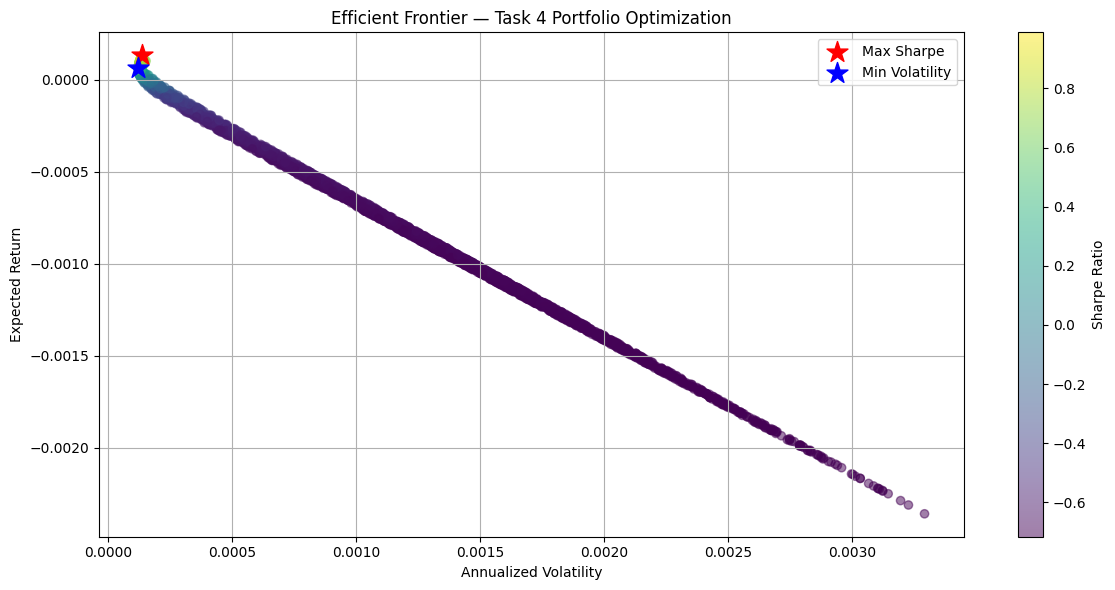

In [9]:
# %% [code]
plt.figure(figsize=(12,6))
plt.scatter(portfolio_df["Volatility"], portfolio_df["Return"], c=portfolio_df["Sharpe"], cmap="viridis", alpha=0.5)
plt.colorbar(label="Sharpe Ratio")
plt.scatter(max_sharpe_port["Volatility"], max_sharpe_port["Return"], color="r", marker="*", s=250, label="Max Sharpe")
plt.scatter(min_vol_port["Volatility"], min_vol_port["Return"], color="b", marker="*", s=250, label="Min Volatility")
plt.title("Efficient Frontier — Task 4 Portfolio Optimization")
plt.xlabel("Annualized Volatility")
plt.ylabel("Expected Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_folder, "efficient_frontier.png"), dpi=300)
plt.show()


In [10]:
# %% [code]
print("✅ Maximum Sharpe Ratio Portfolio")
print(max_sharpe_port[tickers].to_frame().T)
print(f"Expected Return: {max_sharpe_port['Return']:.2%}")
print(f"Volatility: {max_sharpe_port['Volatility']:.2%}\n")

print("✅ Minimum Volatility Portfolio")
print(min_vol_port[tickers].to_frame().T)
print(f"Expected Return: {min_vol_port['Return']:.2%}")
print(f"Volatility: {min_vol_port['Volatility']:.2%}\n")


✅ Maximum Sharpe Ratio Portfolio
         tsla       bnd       spy
4087  0.00278  0.986419  0.010802
Expected Return: 0.01%
Volatility: 0.01%

✅ Minimum Volatility Portfolio
          tsla       bnd      spy
2596  0.021579  0.473991  0.50443
Expected Return: 0.01%
Volatility: 0.01%

